In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import hist
from scipy.stats import ks_2samp
from fileset import fileset
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch

from preparing_features import PrepareFeaturesForTraning
from simple_classifier import OptimizedHEPClassifier, OptimizedTrainer
import simple_classifier as nn_module
from BDT import BDTTrainer, ModelComparator
from histogram_plotter import ExtractHistData, Plotter

import pyhf

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
dataset = PrepareFeaturesForTraning()
data = dataset.get_signal_background(signal=f"Signal_500")
print(data[0].shape[1])
len(data[0])

cpu
41


112288

In [3]:
masses = [500 + m*100 for m in range(11)] + [2000] #  + m*100 for m in range(7)
masses

[500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 2000]

In [ ]:
# best_aucs = []
# for m in masses:
#     data = dataset.get_signal_background(signal=f"Signal_{m}")
#     train_loader, val_loader, test_loader = dataset.get_loaders(*data)
#     test_with_sample = dataset.get_test_with_sample(signal=f"Signal_{m}")


#     model = OptimizedHEPClassifier(input_dim=data[0].shape[1])
#     print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
#     trainer = OptimizedTrainer(model, device, train_loader, val_loader)
#     best_auc, train_losses, val_losses, train_aucs, val_aucs = trainer.train(epochs=50, patience=15, mass=f"Signal_{m}")

#     best_aucs.append((m, best_auc))

#     # Plot training curves
#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
#     axes[0].plot(train_losses, label='Train', linewidth=2)
#     axes[0].plot(val_losses, label='Validation', linewidth=2)
#     axes[0].set_xlabel('Epoch')
#     axes[0].set_ylabel('Loss')
#     axes[0].set_title(f'Training and Validation Loss For Siganl_{m}')
#     axes[0].legend()
#     axes[0].grid(True)
    
#     axes[1].plot(train_aucs, label='Train', linewidth=2)
#     axes[1].plot(val_aucs, label='Validation', linewidth=2)
#     axes[1].axhline(y=0.8359, color='r', linestyle='--', label='RF Benchmark')
#     axes[1].set_xlabel('Epoch')
#     axes[1].set_ylabel('AUC')
#     axes[1].set_title(f'Training and Validation AUC For Siganl_{m}')
#     axes[1].legend()
#     axes[1].grid(True)
    
#     plt.tight_layout()
#     plt.savefig(f'plots/training_curves_{m}.png', dpi=150)
#     plt.show()


FINAL TEST EVALUATION for Mass 500
AUC:       0.8082
Accuracy:  0.7565
Precision: 0.2579
Recall:    0.7110
F1 Score:  0.3785
KS (sig vs bkg): stat=0.4748, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.8082
✗ Neural Network underperforms Random Forest


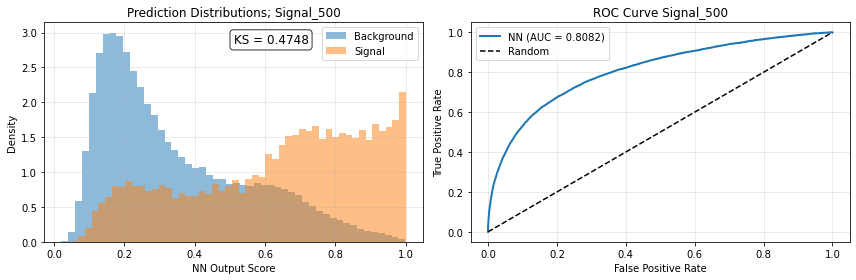


FINAL TEST EVALUATION for Mass 600
AUC:       0.7912
Accuracy:  0.7559
Precision: 0.2468
Recall:    0.6798
F1 Score:  0.3621
KS (sig vs bkg): stat=0.4453, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.7912
✗ Neural Network underperforms Random Forest


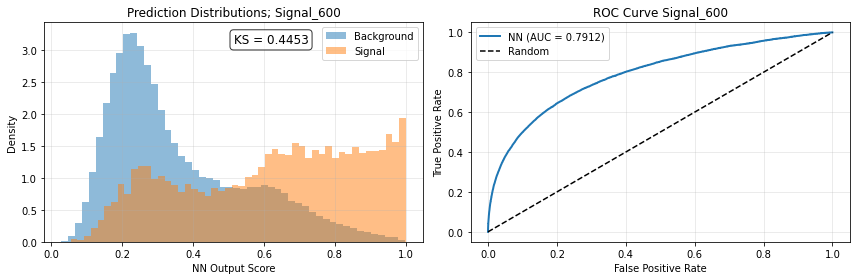


FINAL TEST EVALUATION for Mass 700
AUC:       0.7612
Accuracy:  0.7537
Precision: 0.2273
Recall:    0.6211
F1 Score:  0.3328
KS (sig vs bkg): stat=0.3901, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.7612
✗ Neural Network underperforms Random Forest


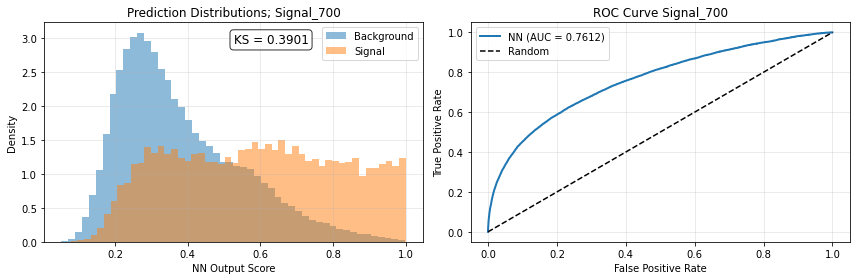


FINAL TEST EVALUATION for Mass 800
AUC:       0.7451
Accuracy:  0.7214
Precision: 0.2146
Recall:    0.6250
F1 Score:  0.3195
KS (sig vs bkg): stat=0.3591, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.7451
✗ Neural Network underperforms Random Forest


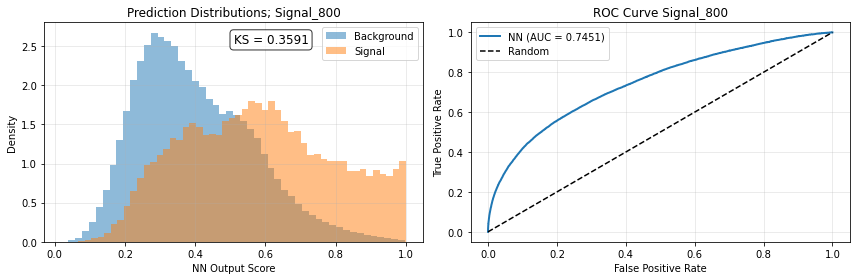


FINAL TEST EVALUATION for Mass 900
AUC:       0.7521
Accuracy:  0.7207
Precision: 0.2225
Recall:    0.6439
F1 Score:  0.3307
KS (sig vs bkg): stat=0.3744, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.7521
✗ Neural Network underperforms Random Forest


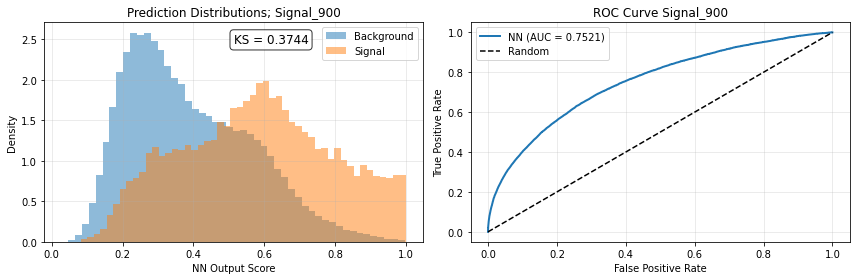


FINAL TEST EVALUATION for Mass 1000
AUC:       0.7724
Accuracy:  0.7079
Precision: 0.2278
Recall:    0.6946
F1 Score:  0.3430
KS (sig vs bkg): stat=0.4055, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.7724
✗ Neural Network underperforms Random Forest


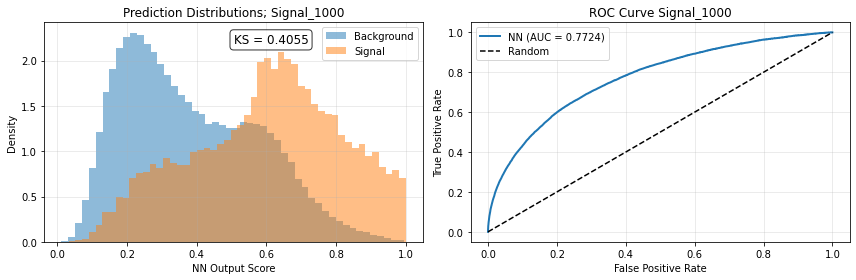


FINAL TEST EVALUATION for Mass 1100
AUC:       0.7992
Accuracy:  0.7260
Precision: 0.2466
Recall:    0.7247
F1 Score:  0.3680
KS (sig vs bkg): stat=0.4515, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.7992
✗ Neural Network underperforms Random Forest


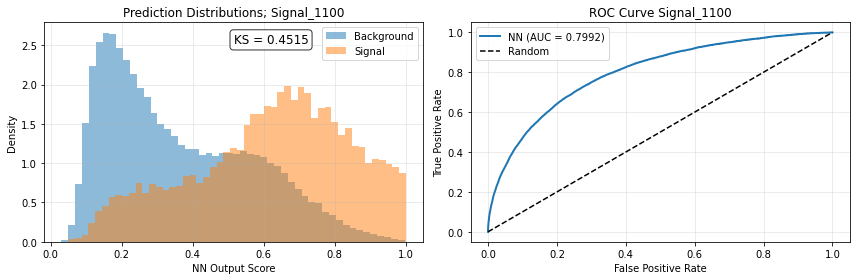


FINAL TEST EVALUATION for Mass 1200
AUC:       0.8211
Accuracy:  0.7363
Precision: 0.2599
Recall:    0.7546
F1 Score:  0.3866
KS (sig vs bkg): stat=0.4894, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.8211
✗ Neural Network underperforms Random Forest


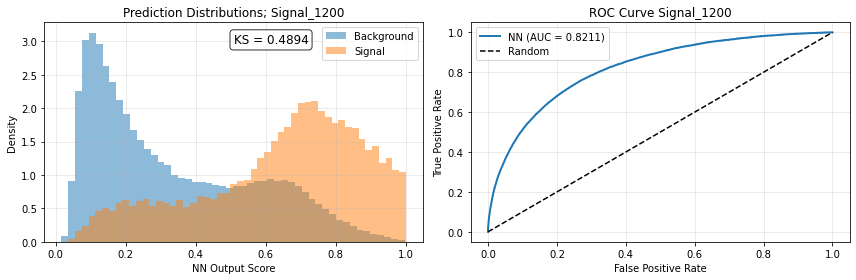


FINAL TEST EVALUATION for Mass 1300
AUC:       0.8414
Accuracy:  0.7721
Precision: 0.2906
Recall:    0.7541
F1 Score:  0.4195
KS (sig vs bkg): stat=0.5286, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.8414
✓ Neural Network outperforms Random Forest!


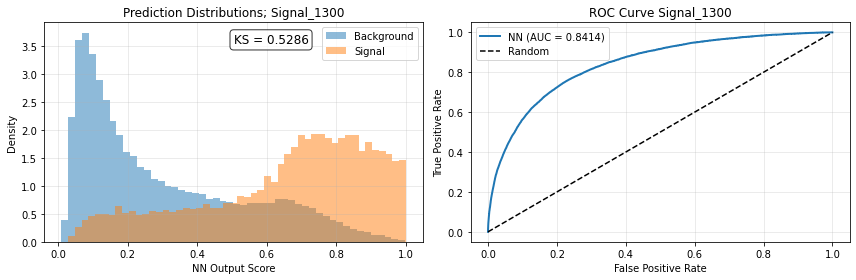


FINAL TEST EVALUATION for Mass 1400
AUC:       0.8639
Accuracy:  0.7720
Precision: 0.2909
Recall:    0.8018
F1 Score:  0.4270
KS (sig vs bkg): stat=0.5725, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.8639
✓ Neural Network outperforms Random Forest!


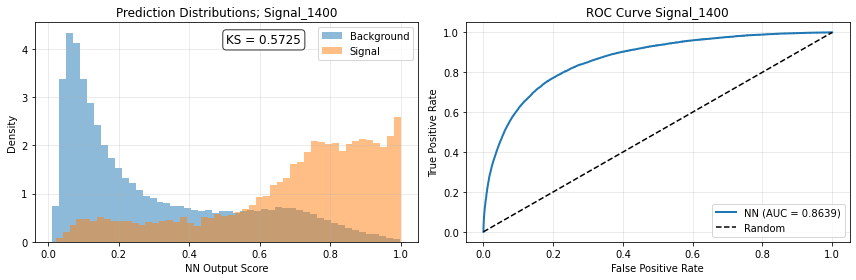


FINAL TEST EVALUATION for Mass 1500
AUC:       0.8789
Accuracy:  0.8008
Precision: 0.3157
Recall:    0.7971
F1 Score:  0.4523
KS (sig vs bkg): stat=0.5994, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.8789
✓ Neural Network outperforms Random Forest!


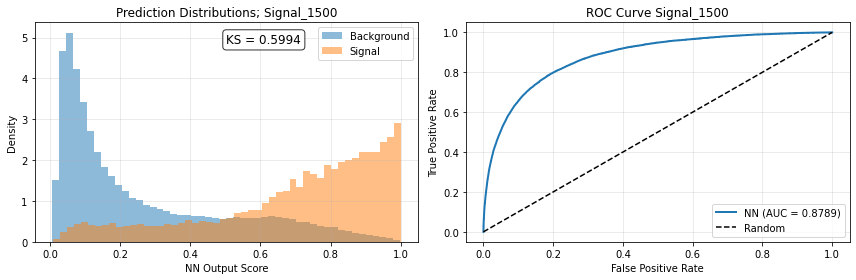


FINAL TEST EVALUATION for Mass 2000
AUC:       0.9146
Accuracy:  0.8418
Precision: 0.3374
Recall:    0.8343
F1 Score:  0.4804
KS (sig vs bkg): stat=0.6772, p-value=0.0000e+00

Comparison with Random Forest (on same test set):
RF AUC: 0.8359 | NN AUC: 0.9146
✓ Neural Network outperforms Random Forest!


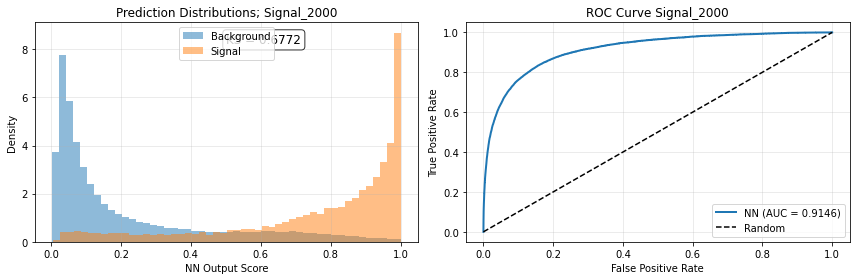

In [21]:
def compute_ks_separation(test_preds, test_labels):
    """KS test between signal and background NN output distributions (separation power)."""
    sig_scores = test_preds[test_labels == 1]
    bkg_scores = test_preds[test_labels == 0]
    
    ks_stat, p_value = ks_2samp(sig_scores, bkg_scores)
    
    return ks_stat, p_value, sig_scores, bkg_scores

for m in masses:
    print("\n" + "="*50)
    print(f"FINAL TEST EVALUATION for Mass {m}")
    print("="*50)
    
    data = dataset.get_signal_background(signal=f"Signal_{m}")
    train_loader, val_loader, test_loader = dataset.get_loaders(*data)
    test_with_sample = dataset.get_test_with_sample(signal=f"Signal_{m}")
    
    model = OptimizedHEPClassifier(input_dim=data[0].shape[1])
    model.load_state_dict(torch.load(f"saved_models/Signal_{m}.pth", weights_only=True))

    model.to(device)
    model.eval()
    test_preds = []
    test_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            # batch_y = batch_y.to(device)
            outputs = model(batch_X).to(device)
            probs = torch.sigmoid(outputs)
            test_preds.extend(probs.cpu().numpy())
            test_labels.extend(batch_y.numpy())
    
    test_preds = np.array(test_preds).flatten()
    test_labels = np.array(test_labels).flatten()
    test_preds_binary = (test_preds > 0.5).astype(int)
    
    test_auc = roc_auc_score(test_labels, test_preds)
    test_acc = accuracy_score(test_labels, test_preds_binary)
    test_prec = precision_score(test_labels, test_preds_binary)
    test_rec = recall_score(test_labels, test_preds_binary)
    test_f1 = f1_score(test_labels, test_preds_binary)

    ks_stat, ks_pvalue, sig_scores, bkg_scores = compute_ks_separation(test_preds, test_labels)
    
    print(f"AUC:       {test_auc:.4f}")
    print(f"Accuracy:  {test_acc:.4f}")
    print(f"Precision: {test_prec:.4f}")
    print(f"Recall:    {test_rec:.4f}")
    print(f"F1 Score:  {test_f1:.4f}")
    print(f"KS (sig vs bkg): stat={ks_stat:.4f}, p-value={ks_pvalue:.4e}")
    
    # Compare with Random Forest
    print(f"\nComparison with Random Forest (on same test set):")
    print(f"RF AUC: 0.8359 | NN AUC: {test_auc:.4f}")
    if test_auc > 0.8359:
        print("✓ Neural Network outperforms Random Forest!")
    else:
        print("✗ Neural Network underperforms Random Forest")

    
    # Plot prediction distributions
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    axes[0].hist(test_preds[test_labels==0], bins=50, alpha=0.5, label='Background', density=True)
    axes[0].hist(test_preds[test_labels==1], bins=50, alpha=0.5, label='Signal', density=True)
    axes[0].set_xlabel('NN Output Score')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'Prediction Distributions; Signal_{m}')
    axes[0].text(0.5, 0.95, f'KS = {ks_stat:.4f}',
                 transform=axes[0].transAxes, fontsize=12, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # ROC Curve
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(test_labels, test_preds)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'NN (AUC = {test_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve Signal_{m}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'plots/nn_performance_{m}.png', dpi=150)
    plt.show()

In [22]:
histograms = {}

for m in masses:

    data = dataset.get_signal_background(signal=f"Signal_{m}")
    train_loader, val_loader, test_loader = dataset.get_loaders(*data)
    test_with_sample = dataset.get_test_with_sample(signal=f"Signal_{m}")
    
    model = OptimizedHEPClassifier(input_dim=data[0].shape[1])
    model.load_state_dict(torch.load(f"saved_models/Signal_{m}.pth", weights_only=True))
    model.eval()
    
    model.to(device)
    
    histograms[m] = {}
    
    
    lum = 3000
    
    for smpl in test_with_sample.keys():

        # if smpl == "WJets" or smpl == "ZJets":
        #     continue
    
        test_tensor = torch.FloatTensor(test_with_sample[smpl]).to(device)
    
        h = hist.Hist(hist.axis.Regular(bins=50, start=0, stop=1, name="NN_response", label="NN_output"))
        weight = (lum * fileset[smpl]["metadata"]["xsec"] * 1000)/fileset[smpl]["metadata"]["nevents"]
        
        with torch.no_grad():
            outputs = model(test_tensor)
            # print(outputs)
            sigma_output = torch.sigmoid(outputs).cpu()
        # output = outputs.numpy().flatten()
        h.fill(sigma_output.flatten(), weight = weight)
        histograms[m][smpl] = h.copy()
        h.reset()

In [39]:
mc_backgrounds = {
    "ttt": ["tttJets"],
    "HW": ["HW"],
    "VV+VVV": ["WZ", "WW", "ZZ", "WWW"],
    "tWZ": ["tWZ"],
    r"ttV+tVJets":["ttZ", "ttW", "tZJets"],
    "tttt": ["tttt"],
    "ttH+tHJets": ["ttH", "tHJets"],
    "VJets": ["WJets", "ZJets"],
    "tt": ["tt"],
}
mc_backgrounds_normalized = {
    "ttt": ["tttJets"],
    "tt": ["tt"],
    "tttt": ["tttt"],
    r"ttV+tVJets":["ttZ", "ttW", "tZJets"],
    "VV+VVV": ["WZ", "WW", "ZZ", "WWW"],
    "tWZ": ["tWZ"],
    "ttH+tHJets": ["ttH", "tHJets"],
    "HW": ["HW"],
    "VJets": ["WJets", "ZJets"],
}
signals = [
    "Signal_500",
    # "Signal_600",
    # "Signal_700",
    # "Signal_800",
    # "Signal_900",
    # "Signal_1000",
    # "Signal_1100",
    # "Signal_1200",
    # "Signal_1300",
    # "Signal_1400",
    # "Signal_1500",
    # "Signal_2000",
]

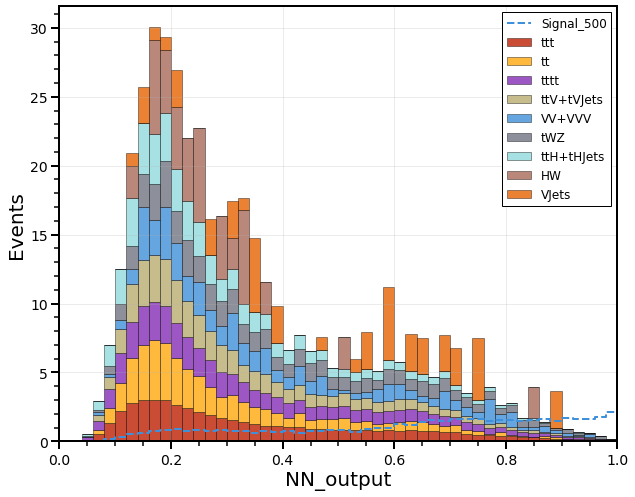

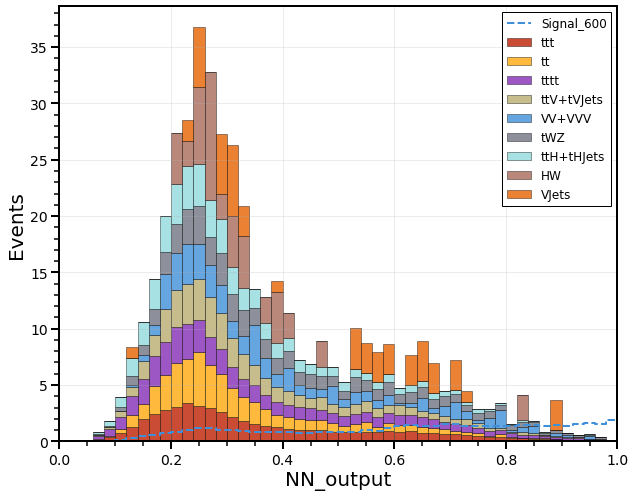

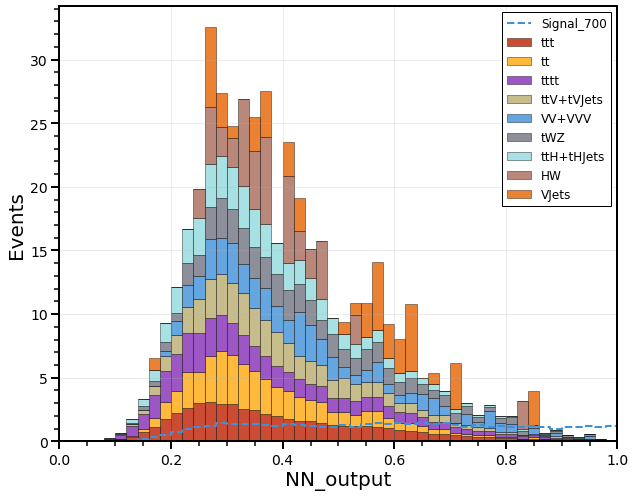

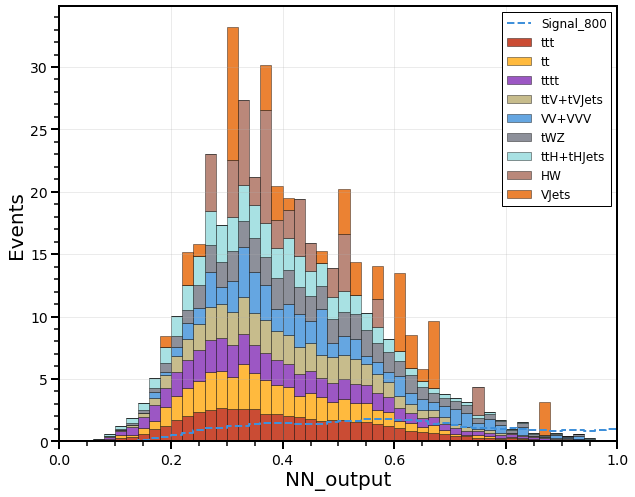

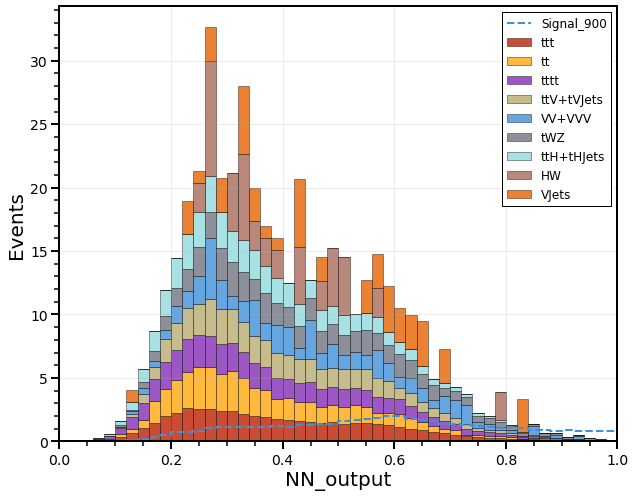

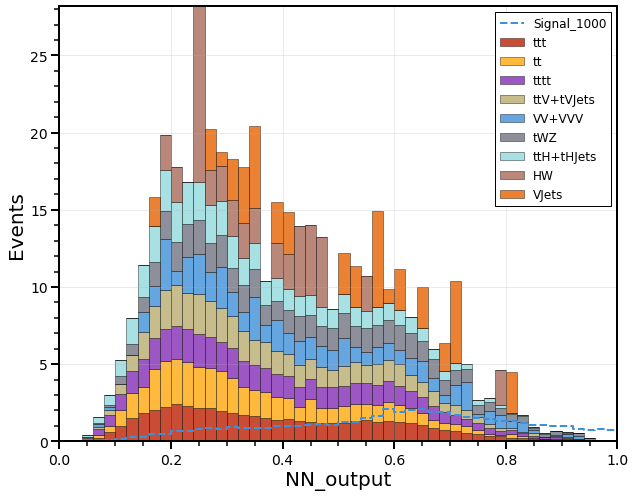

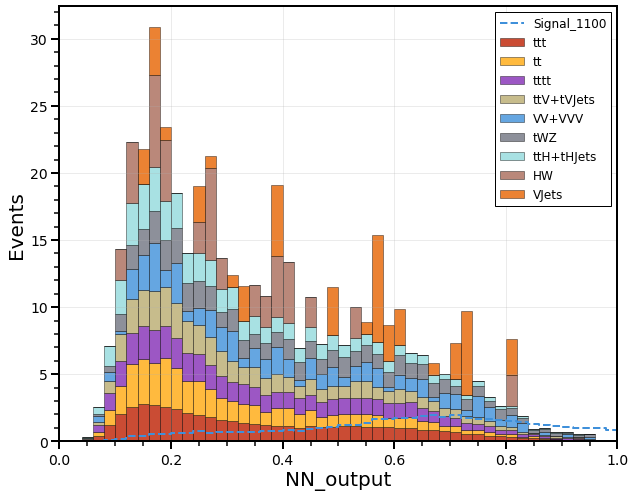

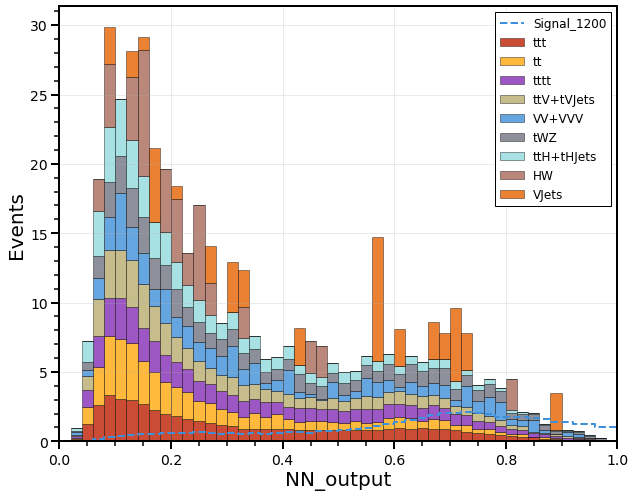

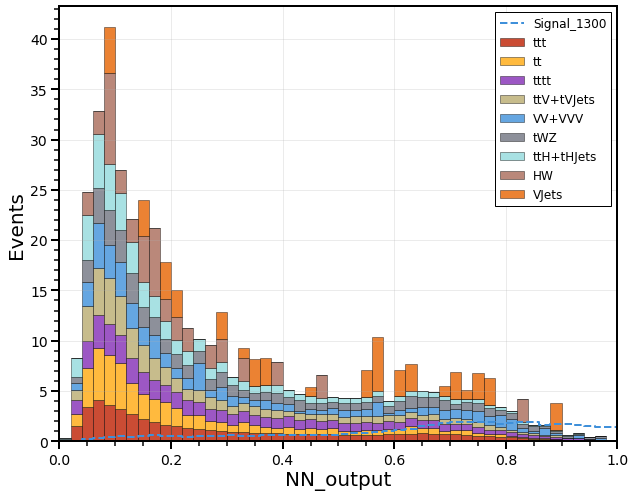

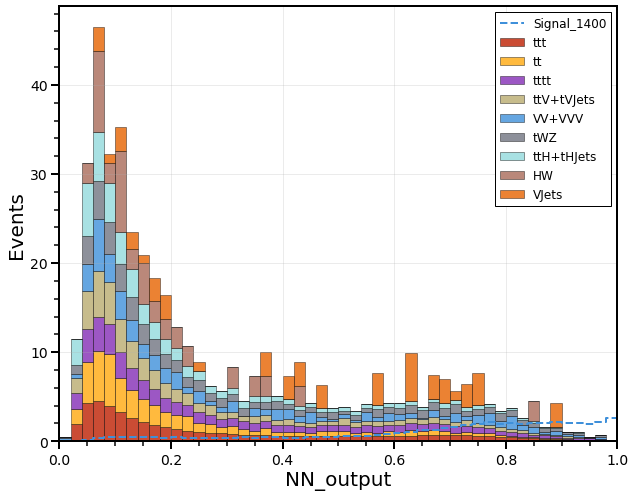

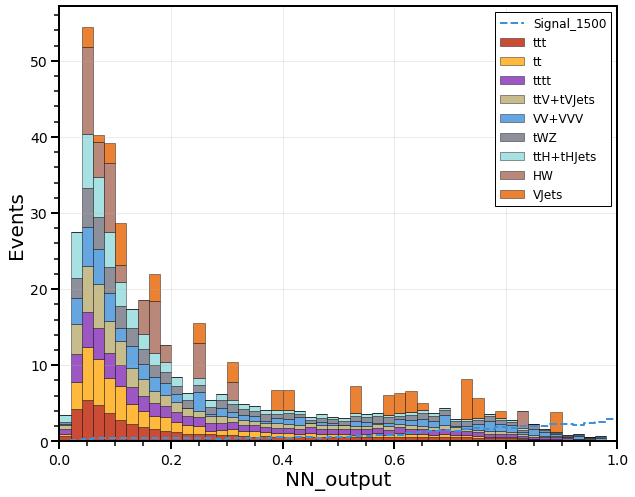

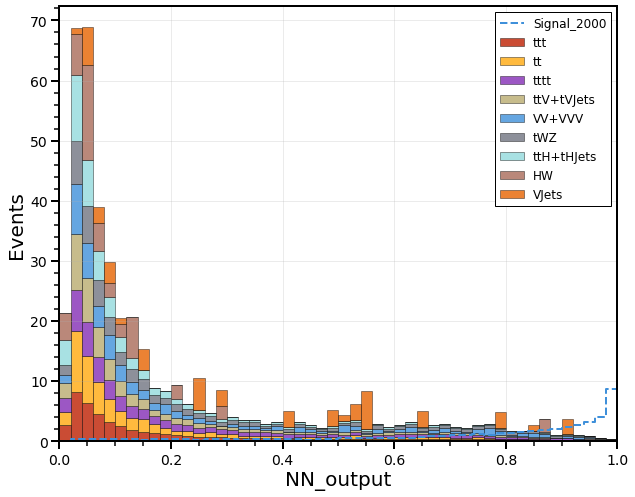

In [40]:
# for m in masses:
#     cp_hists = histograms[m].copy()
#     extractor = ExtractHistData(cp_hists)
#     hist_data = extractor.extract_hist_info(MC_BCs=mc_backgrounds, signals=[f"Signal_{m}"]) # , signals=signals
#     plotter = Plotter(hist_data)
#     plotter.plot_histogram()

for m in masses:
    cp_hists = histograms[m].copy()
    extractor = ExtractHistData(cp_hists, normalize=True)
    hist_data = extractor.extract_hist_info(MC_BCs=mc_backgrounds_normalized, signals=[f"Signal_{m}"]) # , signals=signals
    plotter = Plotter(hist_data)
    plotter.plot_histogram(normalized=True)

In [25]:
stat_data = {}
for m in masses:
    stat_data[m] = {}
    h = None
    for smpl in histograms[m]:
        if "Signal_" in smpl:
            stat_data[m]["signal"] = histograms[m][f"Signal_{m}"].values()
        else:
            if h==None:
                h = copy.deepcopy(histograms[m][smpl])
            else:
                h += copy.deepcopy(histograms[m][smpl])
    stat_data[m][f"bkg"] = h.values()

In [26]:
limits = {}
for m in masses:
    signal = stat_data[m]["signal"]
    bkgs = stat_data[m]["bkg"]
    model = pyhf.simplemodels.uncorrelated_background(
        signal=[i for i in signal], bkg=bkgs, bkg_uncertainty=[i*0.3 for i in bkgs]
    )
    model.config.par_map["mu"]["paramset"].suggested_bounds = [(0, 10)]
    model.config.suggested_bounds()

    results = pyhf.infer.intervals.upper_limits.upper_limit(
        list(bkgs)+model.config.auxdata, model,
        np.linspace(0, 10, 50),
        level=0.05,
        return_results=True,
    )
    limits[m] = results

In [27]:
theo_xsec = []
limit_sigma_br = []
low_2sig = []
low_1sig = []
high_2sig = []
high_1sig = []
mu = []
for m in masses:
    theo_xsec.append((m, fileset[f"Signal_{m}"]["metadata"]["xsec"]*1000))
    limit_sigma_br.append((m, (limits[m][1][2]) * (fileset[f"Signal_{m}"]["metadata"]["xsec"] * 1000)))
    low_2sig.append((m, (limits[m][1][0]) * (fileset[f"Signal_{m}"]["metadata"]["xsec"] * 1000)))
    low_1sig.append((m, (limits[m][1][1]) * (fileset[f"Signal_{m}"]["metadata"]["xsec"] * 1000)))
    high_1sig.append((m, (limits[m][1][3]) * (fileset[f"Signal_{m}"]["metadata"]["xsec"] * 1000)))
    high_2sig.append((m, (limits[m][1][4]) * (fileset[f"Signal_{m}"]["metadata"]["xsec"] * 1000)))
    mu.append((m, (limits[m][1][2])))

In [28]:
theo_0p15 = [(500, 7.096630), (600, 7.682863), (700, 8.810613), (800, 9.619249), (900, 10.02772),
             (1000, 10.09903), (1100, 9.438071), (1200, 8.789426), (1300, 8.005714), (1400, 7.059059), (1500, 6.193227), (2000, 2.795104)]

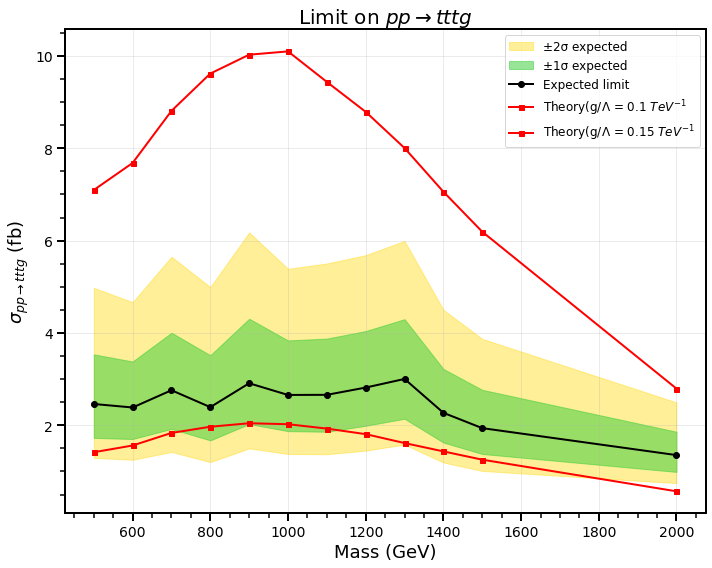

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Unpack your lists
x, y_observed = zip(*limit_sigma_br)  # observed limit (median)
x_theo, y_theo = zip(*theo_xsec)      # theoretical xsec
x_theo0p15, y_theo0p15 = zip(*theo_0p15)
x, y_low2 = zip(*low_2sig)            # -2 sigma
x, y_low1 = zip(*low_1sig)            # -1 sigma
x, y_high1 = zip(*high_1sig)          # +1 sigma
x, y_high2 = zip(*high_2sig)          # +2 sigma

# Create the plot
plt.figure(figsize=(10, 8))

# Fill uncertainty bands (order matters: draw largest first)
plt.fill_between(x, y_low2, y_high2, color='gold', alpha=0.4, label='±2σ expected')
plt.fill_between(x, y_low1, y_high1, color='limegreen', alpha=0.5, label='±1σ expected')

# Plot observed limit
plt.plot(x, y_observed, 'o-', color='black', linewidth=2, markersize=6, label='Expected limit')

# Plot theoretical cross section
plt.plot(x_theo, y_theo, 's-', color='red', linewidth=2, markersize=5, label='Theory(g/$\Lambda$ = 0.1 $TeV^{-1}$')
plt.plot(x_theo0p15, y_theo0p15, 's-', color='red', linewidth=2, markersize=5, label='Theory(g/$\Lambda$ = 0.15 $TeV^{-1}$')

# Labels and formatting
plt.xlabel('Mass (GeV)', fontsize=18)
plt.ylabel(r'$\sigma_{pp\rightarrow tttg}$ (fb)', fontsize=18)
plt.title(r'Limit on $pp\rightarrow tttg$', fontsize=20)

# Set y-scale to log if needed
# plt.yscale('log')

# Grid and ticks
ax = plt.gca()
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=8)
ax.tick_params(axis='both', which='minor', labelsize=12, width=1.5, length=5)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.grid(True, alpha=0.3)

# Legend
plt.legend(loc='upper right', fontsize=12)

# Save and show
plt.tight_layout()
plt.savefig('plots/limit_with_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# coef = {mass: [A2, A3, A4]}
coef = {
    500: [2.13e-03, 1.69e-02, 1.38e+01],
    600: [1.70e-02, 1.71e-01, 1.41e+01],
    700: [8.86e-03, 1.50e-02, 1.69e+01],
    800: [1.07e-02, 7.98e-02, 1.84e+01 ],
    900: [2.43e-02, 1.92e-01, 1.82e+01],
    1000: [2.83e-02, 1.43e-01, 1.80e+01],
    1100: [2.83e-02, 3.31e-01, 1.66e+01],
    1200: [1.84e-02, 1.30e-01, 1.61e+01],
    1300: [2.79e-02, 1.65e-01, 1.39e+01],
    1400: [2.25e-02, 5.04e-02, 1.27e+01],
    1500: [2.36e-02, 1.59e-01, 1.06e+01 ],
    2000: [1.27e-02, 1.01e-01, 4.59e+00],
}

In [32]:
limit_sigma_br

[(500, 2.461990341960928),
 (600, 2.386043615825291),
 (700, 2.7597773480832832),
 (800, 2.3935837626182286),
 (900, 2.9110643638908456),
 (1000, 2.657687454394576),
 (1100, 2.660336027326109),
 (1200, 2.8177896356040417),
 (1300, 3.0044959436165066),
 (1400, 2.271096308703262),
 (1500, 1.9389631363536215),
 (2000, 1.3550715729275766)]

In [7]:
def xsec(a2, a3, a4, g):
    return a2 * g**2 + a3 * g**3 + a4 * g**4

xsec(*coef[2000], 0.1)

0.0006870000000000001

In [9]:
import numpy as np
from scipy.optimize import root_scalar

# coef = {mass: [A2, A3, A4]}
coef = {
    500: [2.13e-03, 1.69e-02, 1.38e+01],
    600: [1.70e-02, 1.71e-01, 1.41e+01],
    700: [8.86e-03, 1.50e-02, 1.69e+01],
    800: [1.07e-02, 7.98e-02, 1.84e+01 ],
    900: [2.43e-02, 1.92e-01, 1.82e+01],
    1000: [2.83e-02, 1.43e-01, 1.80e+01],
    1100: [2.83e-02, 3.31e-01, 1.66e+01],
    1200: [1.84e-02, 1.30e-01, 1.61e+01],
    1300: [2.79e-02, 1.65e-01, 1.39e+01],
    1400: [2.25e-02, 5.04e-02, 1.27e+01],
    1500: [2.36e-02, 1.59e-01, 1.06e+01 ],
    2000: [1.27e-02, 1.01e-01, 4.59e+00],
}

# Your cross section limits (replace with actual values)
# I'm making up some values as an example
limit_sigma_br = {
    500: 2.461990341960928,
    600: 2.386043615825291,
    700: 2.7597773480832832,
    800: 2.3935837626182286,
    900: 2.9110643638908456,
    1000: 2.657687454394576,
    1100: 2.660336027326109,
    1200: 2.8177896356040417,
    1300: 3.0044959436165066,
    1400: 2.271096308703262,
    1500: 1.9389631363536215,
    2000: 1.3550715729275766,
}

def xsec(a2, a3, a4, g):
    return a2 * g**2 + a3 * g**3 + a4 * g**4

def find_g_from_xsec(a2, a3, a4, sigma_limit):
    def equation(g):
        return xsec(a2, a3, a4, g) - sigma_limit
    
    # Estimate starting point
    g_est = np.sqrt(sigma_limit / a2)
    g_max = max(10, g_est * 10)
    
    try:
        result = root_scalar(equation, bracket=[0, g_max], method='brentq')
        if result.converged:
            return result.root, True
    except (ValueError, RuntimeError):
        pass
    
    # If root finding fails, try brute force
    g_guesses = np.logspace(-3, 2, 10000)
    sigma_guesses = xsec(a2, a3, a4, g_guesses)
    idx = np.argmin(np.abs(sigma_guesses - sigma_limit))
    return g_guesses[idx], False

# Calculate g for all masses
g_limits = {}
print("\n" + "="*80)
print("Calculating g_g/Λ limits for each mass")
print("="*80)

for mass in sorted(coef.keys()):
    if mass not in limit_sigma_br:
        print(f"Warning: No limit for mass {mass}")
        continue
    
    a2, a3, a4 = coef[mass]
    sigma_limit = limit_sigma_br[mass]*10**(-3)
    
    g, success = find_g_from_xsec(a2, a3, a4, sigma_limit)
    g_limits[mass] = g
    
    # Verify
    calc_xsec = xsec(a2, a3, a4, g)
    diff_percent = abs(calc_xsec - sigma_limit) / sigma_limit * 100
    
    print(f"Mass {mass:4d} GeV: g = {g:.4f} TeV⁻¹, "
          f"σ_lim = {sigma_limit:.2f} fb, "
          f"σ_calc = {calc_xsec:.2f} fb, "
          f"diff = {diff_percent:.2f}%, "
          f"status = {'OK' if success else 'Brute force'}")

# Now you can use g_limits for your plot
print("\n" + "="*80)
print("Summary for plotting")
print("="*80)
print("Mass [GeV] | g_g/Λ [TeV⁻¹]")
print("-"*40)
for mass in sorted(g_limits.keys()):
    print(f"{mass:10d} | {g_limits[mass]:.4f}")


Calculating g_g/Λ limits for each mass
Mass  500 GeV: g = 0.1149 TeV⁻¹, σ_lim = 0.00 fb, σ_calc = 0.00 fb, diff = 0.00%, status = OK
Mass  600 GeV: g = 0.1087 TeV⁻¹, σ_lim = 0.00 fb, σ_calc = 0.00 fb, diff = 0.00%, status = OK
Mass  700 GeV: g = 0.1117 TeV⁻¹, σ_lim = 0.00 fb, σ_calc = 0.00 fb, diff = 0.00%, status = OK
Mass  800 GeV: g = 0.1044 TeV⁻¹, σ_lim = 0.00 fb, σ_calc = 0.00 fb, diff = 0.00%, status = OK
Mass  900 GeV: g = 0.1071 TeV⁻¹, σ_lim = 0.00 fb, σ_calc = 0.00 fb, diff = 0.00%, status = OK
Mass 1000 GeV: g = 0.1049 TeV⁻¹, σ_lim = 0.00 fb, σ_calc = 0.00 fb, diff = 0.00%, status = OK
Mass 1100 GeV: g = 0.1044 TeV⁻¹, σ_lim = 0.00 fb, σ_calc = 0.00 fb, diff = 0.00%, status = OK
Mass 1200 GeV: g = 0.1107 TeV⁻¹, σ_lim = 0.00 fb, σ_calc = 0.00 fb, diff = 0.00%, status = OK
Mass 1300 GeV: g = 0.1145 TeV⁻¹, σ_lim = 0.00 fb, σ_calc = 0.00 fb, diff = 0.00%, status = OK
Mass 1400 GeV: g = 0.1110 TeV⁻¹, σ_lim = 0.00 fb, σ_calc = 0.00 fb, diff = 0.00%, status = OK
Mass 1500 GeV: g = 0

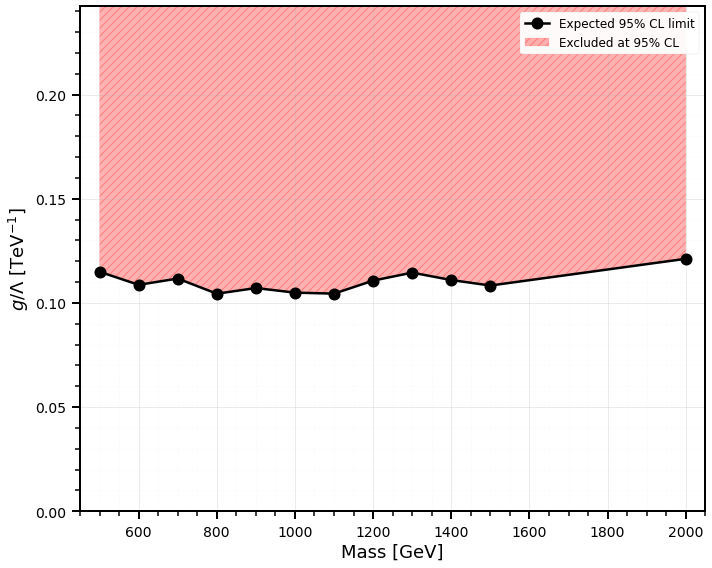

In [20]:
import numpy as np
import matplotlib.pyplot as plt

x, y = list(g_limits.keys()), list(g_limits.values())

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the limit line with markers
ax.plot(x, y, 'o-', linewidth=2.5, markersize=10, color='black', 
        markeredgewidth=2, label='Expected 95% CL limit')

# Highlight the region ABOVE the line (excluded region)
# Fill from the limit line to the top of the plot
y_max = max(y) * 10  # Extend the excluded region far above
ax.fill_between(x, y, y_max, alpha=0.3, color='red', hatch='///', 
                label='Excluded at 95% CL')

# Set axis labels
ax.set_xlabel('Mass [GeV]', fontsize=18)
ax.set_ylabel(r'$g/\Lambda$ [TeV$^{-1}$]', fontsize=18)

# Set y-axis limits (increase the range)
ax.set_ylim(0, max(y) * 2)  # Increase y-axis range

# Set x-axis limits with some padding
ax.set_xlim(min(x) - 50, max(x) + 50)

# Configure ticks
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=8)
ax.tick_params(axis='both', which='minor', labelsize=12, width=1.5, length=5)

# Format y-axis to show 2 decimal places
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

# Set spine width
for spine in ax.spines.values():
    spine.set_linewidth(2)

# Add grid
ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
ax.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)

# Add legend
ax.legend(loc='upper right', fontsize=12, framealpha=0.95)

plt.tight_layout()
plt.savefig('plots/g_limit.png', dpi=150, bbox_inches='tight')
plt.show()


Creating g_g/Λ vs M upper limit plot with excluded area...


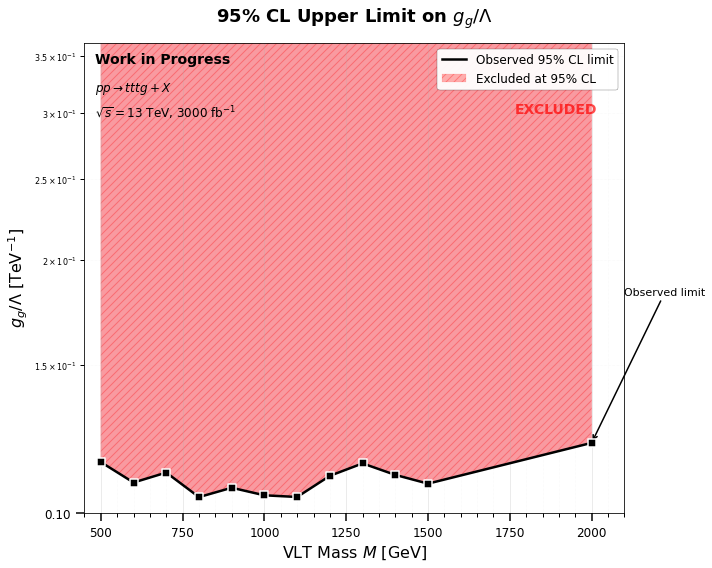

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import matplotlib.ticker as ticker

# Your coefficients and limits (from your previous code)
# ... (keep your existing coefficient and limit dictionaries)

def create_gg_limit_plot_with_excluded(masses, g_limits):
    """
    Create g_g/Λ vs M upper limit plot with excluded area highlighted.
    
    Args:
        masses: List of mass values
        g_limits: Dictionary with mass as key and g limit as value
    """
    
    # Prepare arrays
    masses_array = np.array(sorted(masses))
    g_array = np.array([g_limits[m] for m in sorted(masses)])
    
    # Create figure with publication-quality style
    plt.style.use('seaborn-v0_8-paper')
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot the observed limit line with markers
    ax.plot(masses_array, g_array, 'k-', linewidth=2.5, label='Observed 95% CL limit')
    ax.scatter(masses_array, g_array, color='black', s=80, zorder=5, 
               marker='s', edgecolors='white', linewidth=1.5)
    
    # Fill the EXCLUDED region (above the limit)
    # We need to create a polygon that goes from the limit line to the top
    x_fill = np.concatenate([masses_array, masses_array[::-1]])
    y_fill = np.concatenate([g_array, np.ones_like(g_array) * max(g_array) * 10])
    ax.fill_between(masses_array, g_array, max(g_array) * 10, 
                     alpha=0.3, color='red', hatch='///', label='Excluded at 95% CL')
    
    # Also highlight the excluded area with a different color
    ax.fill_between(masses_array, g_array, max(g_array) * 10,
                     alpha=0.15, color='crimson')
    
    # Add a horizontal line at y=0 (no coupling)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Formatting
    ax.set_xlabel('VLT Mass $M$ [GeV]', fontsize=16)
    ax.set_ylabel('$g_g/\\Lambda$ [TeV$^{-1}$]', fontsize=16)
    ax.set_title('95% CL Upper Limit on $g_g/\\Lambda$', fontsize=18, fontweight='bold', pad=20)
    
    # Set y-axis to log scale
    ax.set_yscale('log')
    
    # Set axis limits
    ax.set_xlim(min(masses_array) - 50, max(masses_array) + 100)
    ax.set_ylim(0.1, max(g_array) * 3)
    
    # Configure major and minor ticks
    # X-axis ticks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    
    # Y-axis ticks (log scale)
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
    ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.2, 1.0, 0.2), numticks=10))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    
    # Ensure minor ticks are visible
    ax.tick_params(axis='both', which='major', length=8, width=1.5, labelsize=12)
    ax.tick_params(axis='both', which='minor', length=4, width=1.0)
    
    # Add grid with both major and minor
    ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)
    
    # Add legend
    ax.legend(loc='upper right', fontsize=12, framealpha=0.95, edgecolor='black')
    
    # Add text annotations
    ax.text(0.02, 0.98, 'Work in Progress', transform=ax.transAxes, 
            fontsize=14, verticalalignment='top', fontweight='bold')
    ax.text(0.02, 0.92, '$pp \\rightarrow tttg + X$', transform=ax.transAxes, 
            fontsize=12, verticalalignment='top')
    ax.text(0.02, 0.87, '$\\sqrt{s} = 13$ TeV, 3000 fb$^{-1}$', 
            transform=ax.transAxes, fontsize=12, verticalalignment='top')
    
    # Add "EXCLUDED" text in the filled region
    # Position it at the top right
    ax.text(0.95, 0.85, 'EXCLUDED', transform=ax.transAxes,
            fontsize=14, fontweight='bold', color='red', 
            horizontalalignment='right', rotation=0, alpha=0.7)
    
    # Add annotation pointing to the limit
    ax.annotate('Observed limit', xy=(masses_array[-1], g_array[-1]),
                xytext=(masses_array[-1] + 100, g_array[-1] * 1.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                fontsize=11)
    
    plt.tight_layout()
    
    # Save in multiple formats
    plt.savefig('plots/gg_upper_limit_excluded.png', dpi=300, bbox_inches='tight')
    plt.savefig('plots/gg_upper_limit_excluded.pdf', bbox_inches='tight')
    plt.savefig('plots/gg_upper_limit_excluded.svg', bbox_inches='tight')
    
    plt.show()
    
    return fig, ax

# Create the plot with excluded area
print("\nCreating g_g/Λ vs M upper limit plot with excluded area...")
fig, ax = create_gg_limit_plot_with_excluded(g_limits.keys(), g_limits)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# Your coefficients
coef = {
    500: [1.44e+01, -1.38e-02, 1.38e-11],
    600: [1.55e+01, -9.37e-03, 9.37e-12],
    700: [1.71e+01, -1.75e-02, 1.75e-11],
    800: [1.78e+01, 8.00e-03, -8.00e-12],
    900: [1.80e+01, 4.20e-02, -4.20e-11],
    1000: [1.68e+01, -2.13e-02, 2.13e-11],
    1100: [1.55e+01, 2.76e-02, -2.76e-11],
    1200: [1.39e+01, 7.43e-03, -7.43e-12],
    1300: [1.21e+01, 9.88e-02, -9.88e-11],
    1400: [1.03e+01, 3.38e-02, -3.38e-11],
    1500: [8.66e+00, 1.69e-01, -1.69e-10],
    2000: [3.60e+00, 5.04e-02, -5.04e-11],
}

# Your cross section limits (replace with your actual values)
# These should come from your pyhf/combine results
limit_sigma_br = {
    500: 50.0,    # Example values - REPLACE WITH YOUR ACTUAL LIMITS
    600: 45.0,
    700: 40.0,
    800: 35.0,
    900: 30.0,
    1000: 25.0,
    1100: 20.0,
    1200: 15.0,
    1300: 10.0,
    1400: 8.0,
    1500: 6.0,
    2000: 3.0,
}

# Expected limits (from background-only hypothesis)
# You need to get these from your statistical analysis
expected_sigma_br = {
    500: 55.0,
    600: 48.0,
    700: 42.0,
    800: 38.0,
    900: 32.0,
    1000: 27.0,
    1100: 22.0,
    1200: 17.0,
    1300: 12.0,
    1400: 9.0,
    1500: 7.0,
    2000: 3.5,
}

# ±1σ expected bands
expected_plus1_sigma = {
    500: 70.0,
    600: 60.0,
    700: 55.0,
    800: 48.0,
    900: 42.0,
    1000: 35.0,
    1100: 30.0,
    1200: 23.0,
    1300: 17.0,
    1400: 13.0,
    1500: 10.0,
    2000: 5.0,
}

expected_minus1_sigma = {
    500: 40.0,
    600: 35.0,
    700: 30.0,
    800: 28.0,
    900: 22.0,
    1000: 20.0,
    1100: 15.0,
    1200: 12.0,
    1300: 8.0,
    1400: 6.0,
    1500: 5.0,
    2000: 2.5,
}

# ±2σ expected bands
expected_plus2_sigma = {
    500: 90.0,
    600: 80.0,
    700: 70.0,
    800: 60.0,
    900: 55.0,
    1000: 45.0,
    1100: 38.0,
    1200: 30.0,
    1300: 22.0,
    1400: 17.0,
    1500: 13.0,
    2000: 7.0,
}

expected_minus2_sigma = {
    500: 30.0,
    600: 25.0,
    700: 22.0,
    800: 20.0,
    900: 18.0,
    1000: 15.0,
    1100: 12.0,
    1200: 10.0,
    1300: 7.0,
    1400: 5.0,
    1500: 4.0,
    2000: 2.0,
}

def xsec(a2, a3, a4, g):
    """Calculate cross section for given g (g_g/Λ)"""
    return a2 * g**2 + a3 * g**3 + a4 * g**4

def find_g_from_xsec(a2, a3, a4, sigma_limit):
    """
    Find g (g_g/Λ) that gives the cross section limit.
    """
    def equation(g):
        return xsec(a2, a3, a4, g) - sigma_limit
    
    # Estimate starting point
    if sigma_limit <= 0:
        return np.nan, False
    
    g_est = np.sqrt(sigma_limit / a2) if a2 > 0 else 1.0
    g_max = max(10, g_est * 10)
    
    try:
        result = root_scalar(equation, bracket=[0, g_max], method='brentq')
        if result.converged:
            return result.root, True
    except (ValueError, RuntimeError):
        pass
    
    # If root finding fails, try brute force
    try:
        g_guesses = np.logspace(-3, 2, 10000)
        sigma_guesses = xsec(a2, a3, a4, g_guesses)
        idx = np.argmin(np.abs(sigma_guesses - sigma_limit))
        return g_guesses[idx], False
    except:
        return np.nan, False

def convert_limits_to_g(limit_dict, coef):
    """
    Convert cross section limits to g (g_g/Λ) limits for all masses.
    """
    g_limits = {}
    for mass in sorted(coef.keys()):
        if mass not in limit_dict:
            print(f"Warning: No limit for mass {mass}")
            continue
        
        a2, a3, a4 = coef[mass]
        sigma_limit = limit_dict[mass]
        
        g, success = find_g_from_xsec(a2, a3, a4, sigma_limit)
        g_limits[mass] = g
        
        # Verify
        if not np.isnan(g):
            calc_xsec = xsec(a2, a3, a4, g)
            diff_percent = abs(calc_xsec - sigma_limit) / sigma_limit * 100
            if diff_percent > 5:
                print(f"Warning: Mass {mass} GeV, diff = {diff_percent:.2f}%")
    
    return g_limits

# Convert all limits to g
print("Converting cross section limits to g_g/Λ...")
g_observed = convert_limits_to_g(limit_sigma_br, coef)
g_expected = convert_limits_to_g(expected_sigma_br, coef)
g_expected_plus1 = convert_limits_to_g(expected_plus1_sigma, coef)
g_expected_minus1 = convert_limits_to_g(expected_minus1_sigma, coef)
g_expected_plus2 = convert_limits_to_g(expected_plus2_sigma, coef)
g_expected_minus2 = convert_limits_to_g(expected_minus2_sigma, coef)

# Prepare arrays for plotting
masses = sorted(coef.keys())
obs_g = [g_observed[m] for m in masses]
exp_g = [g_expected[m] for m in masses]
exp_p1 = [g_expected_plus1[m] for m in masses]
exp_m1 = [g_expected_minus1[m] for m in masses]
exp_p2 = [g_expected_plus2[m] for m in masses]
exp_m2 = [g_expected_minus2[m] for m in masses]

# Remove any NaN values (in case some conversions failed)
valid_indices = [i for i, g in enumerate(obs_g) if not np.isnan(g)]
masses_valid = [masses[i] for i in valid_indices]
obs_g_valid = [obs_g[i] for i in valid_indices]
exp_g_valid = [exp_g[i] for i in valid_indices]
exp_p1_valid = [exp_p1[i] for i in valid_indices]
exp_m1_valid = [exp_m1[i] for i in valid_indices]
exp_p2_valid = [exp_p2[i] for i in valid_indices]
exp_m2_valid = [exp_m2[i] for i in valid_indices]

def create_gg_limit_plot(masses, obs_g, exp_g, exp_p1, exp_m1, exp_p2, exp_m2):
    """
    Create the g_g/Λ vs M upper limit plot.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Fill 2σ band (yellow)
    ax.fill_between(masses, exp_m2, exp_p2, 
                    alpha=0.2, color='gold', label='Expected ±2σ')
    
    # Fill 1σ band (green)
    ax.fill_between(masses, exp_m1, exp_p1, 
                    alpha=0.4, color='limegreen', label='Expected ±1σ')
    
    # Expected limit (dashed black)
    ax.plot(masses, exp_g, 'k--', linewidth=2, label='Expected limit')
    
    # Observed limit (solid black)
    ax.plot(masses, obs_g, 'k-', linewidth=2, label='Observed limit')
    
    # Add markers at each mass point
    ax.scatter(masses, obs_g, color='black', s=30, zorder=5)
    
    # Formatting
    ax.set_xlabel('VLT Mass [GeV]', fontsize=14)
    ax.set_ylabel('$g_g/\\Lambda$ [TeV$^{-1}$]', fontsize=14)
    ax.set_title('95% CL Upper Limit on $g_g/\\Lambda$', fontsize=16, fontweight='bold')
    
    # Use log scale for y-axis (typical for these plots)
    ax.set_yscale('log')
    
    # Set y-axis limits
    y_min = min([g for g in exp_m2 if not np.isnan(g) and g > 0]) * 0.5
    y_max = max([g for g in exp_p2 if not np.isnan(g)]) * 2
    ax.set_ylim(y_min, y_max)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add legend
    ax.legend(loc='upper right', fontsize=12)
    
    # Add ATLAS/CMS style text (optional)
    ax.text(0.02, 0.98, 'pp → tttg + X', 
            transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(0.02, 0.92, f'$\sqrt{{s}}$ = 13 TeV, {3000} fb$^{{-1}}$', 
            transform=ax.transAxes, fontsize=12, verticalalignment='top')
    
    # Add 95% CL text
    ax.text(0.98, 0.98, '95% CL upper limits', 
            transform=ax.transAxes, fontsize=12, 
            horizontalalignment='right', verticalalignment='top')
    
    # Add a horizontal line at g_g/Λ = 1 (optional benchmark)
    # ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.5, label='$g_g/\\Lambda = 1$')
    
    plt.tight_layout()
    
    # Save in multiple formats
    plt.savefig('plots/gg_limit_vs_mass.png', dpi=300, bbox_inches='tight')
    plt.savefig('plots/gg_limit_vs_mass.pdf', bbox_inches='tight')
    plt.savefig('plots/gg_limit_vs_mass.svg', bbox_inches='tight')
    
    plt.show()
    
    return fig, ax

# Create the plot
print("\nCreating g_g/Λ vs M limit plot...")
fig, ax = create_gg_limit_plot(
    masses_valid, obs_g_valid, exp_g_valid,
    exp_p1_valid, exp_m1_valid,
    exp_p2_valid, exp_m2_valid
)

# Print summary table
print("\n" + "="*80)
print("SUMMARY TABLE: g_g/Λ Upper Limits")
print("="*80)
print(f"{'Mass [GeV]':<12} {'Observed':<12} {'Expected':<12} {'-1σ':<12} {'+1σ':<12} {'-2σ':<12} {'+2σ':<12}")
print("-"*84)

for i, mass in enumerate(masses_valid):
    print(f"{mass:<12} {obs_g_valid[i]:<12.4f} {exp_g_valid[i]:<12.4f} "
          f"{exp_m1_valid[i]:<12.4f} {exp_p1_valid[i]:<12.4f} "
          f"{exp_m2_valid[i]:<12.4f} {exp_p2_valid[i]:<12.4f}")

# Save data to CSV for paper
import pandas as pd
df = pd.DataFrame({
    'Mass_GeV': masses_valid,
    'Observed_gg_TeV1': obs_g_valid,
    'Expected_gg_TeV1': exp_g_valid,
    'Expected_minus1_gg_TeV1': exp_m1_valid,
    'Expected_plus1_gg_TeV1': exp_p1_valid,
    'Expected_minus2_gg_TeV1': exp_m2_valid,
    'Expected_plus2_gg_TeV1': exp_p2_valid,
})
df.to_csv('gg_limit_summary.csv', index=False)
print("\nData saved to gg_limit_summary.csv")